# Script to view the changes in species concentration and radiative forcing from rocket launches and object re-entries.

In [1]:
# Import modules
import sys, os
#sys.path.append('/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir')
import numpy as np
import netCDF4
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import cartopy.crs as ccrs
from gamap_colormap import WhGrYlRd
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown
import pandas as pd
import math

# Set up arrays
filepath     = '/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/'
rocketsSim   ='Rockets' 
norocketsSim = 'Baseline'
wave = "Total" # Total, LW, SW

In [2]:
months =['01','02','03','04','05','06','07','08','09','10','11','12']
years = ["2020","2021","2022"]
year_labels = [2020]
lat_plot = np.zeros((len(months)*len(years),46))
count = 0
loc = "Trop"
for year_count,year in enumerate(years):
    print(year)
    for mth in months:
        year_labels.append(int(mth)/12+year_count+2020)
        if year == "2022" and int(mth) > 11:
            #pass
            continue
        # Open the files
        wr  = xr.open_dataset(f'/home/ucfacb0/Scratch/Old_Rocket_Runs/OutputDir/Rockets/FDH_stratonly/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4') 
        nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4' )
        time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]
        
        # Print the radiative forcing for all species.
        if wave == "Total":
            labs,labl = f'RadAllSkySW{loc}_BASE', f'RadAllSkyLW{loc}_BASE'
            radnr = nr[labs].isel(time=0) + nr[labl].isel(time=0)
            radwr = wr[labs].isel(time=0) + wr[labl].isel(time=0)    
        else:
            lab = f'RadAllSky{wave}{loc}_BASE'
            radnr  = nr[lab].isel(time=0)
            radwr  = wr[lab].isel(time=0)       
        
        lat_plot[count,:] = (1000*(radwr - radnr)).mean("lon")
        count += 1  
        

print(len(year_labels),len(lat),np.shape(lat_plot))     
print(year_labels)

2020
2021
2022
37 46 (36, 46)
[2020, 2020.0833333333333, 2020.1666666666667, 2020.25, 2020.3333333333333, 2020.4166666666667, 2020.5, 2020.5833333333333, 2020.6666666666667, 2020.75, 2020.8333333333333, 2020.9166666666667, 2021.0, 2021.0833333333333, 2021.1666666666667, 2021.25, 2021.3333333333333, 2021.4166666666667, 2021.5, 2021.5833333333333, 2021.6666666666667, 2021.75, 2021.8333333333333, 2021.9166666666667, 2022.0, 2022.0833333333333, 2022.1666666666667, 2022.25, 2022.3333333333333, 2022.4166666666667, 2022.5, 2022.5833333333333, 2022.6666666666667, 2022.75, 2022.8333333333333, 2022.9166666666667, 2023.0]


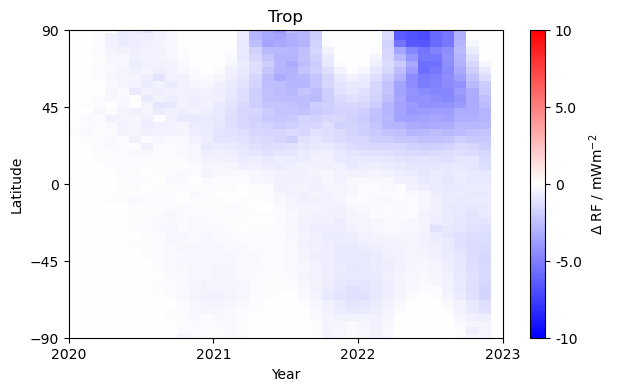

In [3]:
lat = np.linspace(-90-4/2, 90+4/2, 47).clip(-90, 90)

fig, ax = plt.subplots(figsize=(7,4))
order = 10**math.floor(math.log(np.nanmax(np.abs(lat_plot)), 10))
extent = ((np.nanmax(np.abs(lat_plot)) / order)).round(0)*1.5 * order
extent = 10
cf = ax.pcolormesh(year_labels,lat,lat_plot.T, cmap ='bwr', vmin=-extent, vmax=extent,shading='flat')
ax.set_xticks(np.linspace(2020,2023,4))
ax.set_yticks([-90,-45,0,45,90])
ax.set_xlim(2020,2023)
ax.set_xlabel("Year")
ax.set_ylabel("Latitude")
ax.set_title(f"{loc}")
ticks=[-extent, -extent/2, 0, extent/2, extent]
cbar = fig.colorbar(cf, ax=ax, orientation='vertical',ticks=ticks,label="$\Delta$ RF / mWm$^{-2}$")
cbar.ax.set_yticklabels(ticks);

### Script to print the contour maps

In [4]:
def print_contour(diff_mWm2,spec,net):
    fig = plt.figure(figsize=[7,3])
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(linestyle='--')
    cmap_extent = 10
    cf = ax.contourf( lon, lat, diff_mWm2, cmap = 'bwr', levels=np.linspace( -cmap_extent, cmap_extent,100))
    cbar = fig.colorbar(cf, ax=ax, ticks = np.linspace(-cmap_extent, cmap_extent,5),label="$\Delta$ Radiative Forcing / mWm$^{-2}$")
    #ax.set_title(f"Net All-sky {wave} RF at {loc} - {months_passed} months - {spec} ($\mu$ = {net:.2f})")
    ax.set_title(f"{loc} Forcing - {months_passed} months - mean = {net:.2f}")

### Get the radiative forcing data

0.9561921
-2.0405037


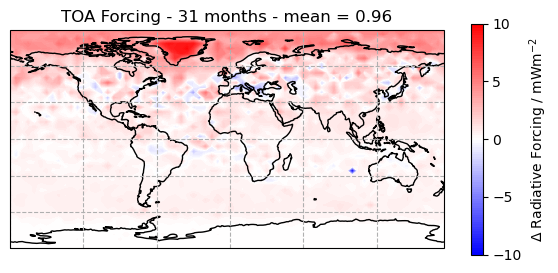

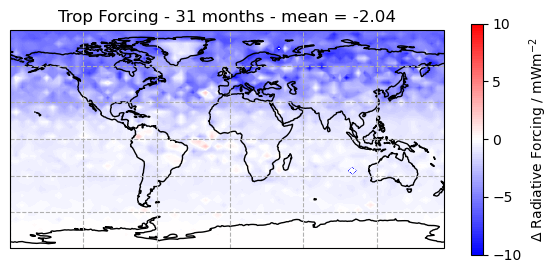

In [5]:
year = "2022"
mth = "07"
months_passed = int(mth) + 12*(int(year)-2020)
wave = "Total" # Total, LW, SW
locs = ["TOA","Trop"]
skipna = True
#species = ["O3","O3T","ME","H2O","SU","NI","AM","BC","OA","SS","DU","PM","ST"]
species = ["DU","BC","O3","ME","H2O"]
rad_diff = np.zeros((len(locs),len(species)))

# Open the files
met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/{year}/GEOSChem.StateMet.{year}{mth}01_0000z.nc4')
try:
    wr  = xr.open_dataset(filepath+rocketsSim+f'/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4') 
except:
    wr  = xr.open_dataset(filepath+rocketsSim+f'/before_atlas_fix/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4') 
nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4' )
time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]


data_stack = np.zeros((len(species),len(locs)))
net = np.zeros((len(locs)))
for loc_count, loc in enumerate(locs):
    
    # Print the radiative forcing for all species.
    if wave == "Total":
        labs,labl = f'RadAllSkySW{loc}_BASE', f'RadAllSkyLW{loc}_BASE'
        radnr = nr[labs].isel(time=0) + nr[labl].isel(time=0)
        radwr = wr[labs].isel(time=0) + wr[labl].isel(time=0)    
    else:
        lab = f'RadAllSky{wave}{loc}_BASE'
        radnr  = nr[lab].isel(time=0)
        radwr  = wr[lab].isel(time=0)       
    
    diff_mWm2 = 1000*(radwr - radnr)
    net[loc_count] = diff_mWm2.mean().values
    print(np.max(diff_mWm2.mean().values))
    print_contour(diff_mWm2,"BASE",net[loc_count])
     
    # Now print the radiative forcing for individual species. 
    for count,spec in enumerate(species):
        
        if wave == "Total":
            labs,labl = f'RadAllSkySW{loc}_{spec}', f'RadAllSkyLW{loc}_{spec}'
            #radnr_spec = (nr[f'RadAllSkySW{loc}_BASE'].isel(time=0) - nr[labs].isel(time=0)) + (nr[f'RadAllSkyLW{loc}_BASE'].isel(time=0) - nr[labl].isel(time=0))
            #radwr_spec = (wr[f'RadAllSkySW{loc}_BASE'].isel(time=0) - wr[labs].isel(time=0)) + (wr[f'RadAllSkyLW{loc}_BASE'].isel(time=0) - wr[labl].isel(time=0))
            radnr_spec = nr[labs].isel(time=0) + nr[labl].isel(time=0)
            radwr_spec = wr[labs].isel(time=0) + wr[labl].isel(time=0)
        else:   
            lab = f'RadAllSky{wave}{loc}_{spec}'    
            #radnr_spec = radnr - nr[lab].isel(time=0)
            #radwr_spec = radwr - wr[lab].isel(time=0)
            radnr_spec = nr[lab].isel(time=0)
            radwr_spec = wr[lab].isel(time=0)
            
        rad_diff[loc_count,count] = np.nanmean(1000*(radwr_spec - radnr_spec))
        diff_mWm2 = 1000*(radwr_spec - radnr_spec)
        
    data = rad_diff[loc_count,:]
    data_shape = np.shape(data)

    # Now build the column plot of species radiative forcing.
    # Take negative and positive data apart and cumulate
    def get_cumulated_array(data, **kwargs):
        cum = data.clip(**kwargs)
        cum = np.cumsum(cum, axis=0)
        d = np.zeros(np.shape(data))
        d[1:] = cum[:-1]
        return d  

    cumulated_data = get_cumulated_array(data, min=0)
    cumulated_data_neg = get_cumulated_array(data, max=0)

    # Re-merge negative and positive data.
    row_mask = (data<0)
    cumulated_data[row_mask] = cumulated_data_neg[row_mask]
    data_stack[:,loc_count] = cumulated_data


[[ 0.01565316  2.98231339 -0.96288961 -0.02570975 -0.42077041]
 [-0.0089448  -2.41085935  0.35304141  0.01160659 -0.09610125]]


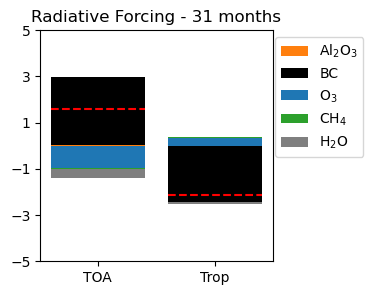

In [6]:
species_list_label = ["Al$_{2}$O$_{3}$","BC","O$_{3}$","CH$_{4}$","H$_{2}$O"]    
width=0.8
color_list = ["tab:orange","k","tab:blue","tab:green","tab:gray"]   
fig = plt.figure(figsize=[3,3])
ax = plt.subplot(111)
for i in np.arange(0, data_shape[0]):
    ax.bar(locs[0], rad_diff[0,i], width=-width, bottom=data_stack[i,0],label=species_list_label[i],color=color_list[i],alpha = 1)
for i in np.arange(0, data_shape[0]):
    ax.bar(locs[1], rad_diff[1,i], width=width, bottom=data_stack[i,1],color=color_list[i],alpha = 1)
ymin = -5
ymax = 5
ax.set_ylim(ymin,ymax)
ax.set_yticks(ticks=np.linspace(ymin,ymax,6))
ax.set_title(f"Radiative Forcing - {months_passed} months")
ax.legend(loc='upper center', bbox_to_anchor=(1.2, 1), ncol=1)
ax.plot([-width/2,width/2],[np.sum(rad_diff[0]),np.sum(rad_diff[0])],ls='--', c='r')
ax.plot([width*0.75,width*1.75],[np.sum(rad_diff[1]),np.sum(rad_diff[1])],ls='--', c='r')
print(rad_diff)

In [7]:
wr.close()
nr.close()
met.close()

### CO2 Check

In [8]:
baseline     = xr.open_dataset(filepath+"co2check/baseline"+f'/GEOSChem.RRTMG.20200101_0000z.nc4')
withoutsa    = xr.open_dataset(filepath+"co2check/withoutsa"+f'/GEOSChem.RRTMG.20200101_0000z.nc4')
withsa       = xr.open_dataset(filepath+"co2check/withsa"+f'/GEOSChem.RRTMG.20200101_0000z.nc4') 
withsa_meso  = xr.open_dataset(filepath+"co2check/withsa_meso"+f'/GEOSChem.RRTMG.20200101_0000z.nc4') 

baseline_toa_flux  = baseline["RadAllSkySWTOA_BASE"].isel(time=0) + baseline["RadAllSkyLWTOA_BASE"].isel(time=0)
baseline_trop_flux = baseline["RadAllSkySWTrop_BASE"].isel(time=0) + baseline["RadAllSkyLWTrop_BASE"].isel(time=0)
baseline_trop_co2_flux = baseline["RadAllSkySWTrop_CO2"].isel(time=0) + baseline["RadAllSkyLWTrop_CO2"].isel(time=0)

withoutsa_toa_flux  = withoutsa["RadAllSkySWTOA_BASE"].isel(time=0) + withoutsa["RadAllSkyLWTOA_BASE"].isel(time=0)
withoutsa_trop_flux = withoutsa["RadAllSkySWTrop_BASE"].isel(time=0) + withoutsa["RadAllSkyLWTrop_BASE"].isel(time=0)
withoutsa_trop_co2_flux = withoutsa["RadAllSkySWTrop_CO2"].isel(time=0) + withoutsa["RadAllSkyLWTrop_CO2"].isel(time=0)
withoutsa_toa_rf = (withoutsa_toa_flux - baseline_toa_flux).mean().values.item()
withoutsa_trop_rf = (withoutsa_trop_flux - baseline_trop_flux).mean().values.item()
withoutsa_trop_co2_rf = (withoutsa_trop_co2_flux - baseline_trop_co2_flux).mean().values.item()
withoutsa_toa_trop = (withoutsa_toa_rf - withoutsa_trop_rf)

withsa_toa_flux  = withsa["RadAllSkySWTOA_BASE"].isel(time=0) + withsa["RadAllSkyLWTOA_BASE"].isel(time=0)
withsa_trop_flux = withsa["RadAllSkySWTrop_BASE"].isel(time=0) + withsa["RadAllSkyLWTrop_BASE"].isel(time=0)
withsa_trop_co2_flux = withsa["RadAllSkySWTrop_CO2"].isel(time=0) + withsa["RadAllSkyLWTrop_CO2"].isel(time=0)
withsa_toa_rf = (withsa_toa_flux - baseline_toa_flux).mean().values.item()
withsa_trop_rf = (withsa_trop_flux - baseline_trop_flux).mean().values.item()
withsa_trop_co2_rf = (withsa_trop_co2_flux - baseline_trop_co2_flux).mean().values.item()
withsa_toa_trop = (withsa_toa_rf - withsa_trop_rf)

withsa_meso_toa_flux  = withsa_meso["RadAllSkySWTOA_BASE"].isel(time=0) + withsa_meso["RadAllSkyLWTOA_BASE"].isel(time=0)
withsa_meso_trop_flux = withsa_meso["RadAllSkySWTrop_BASE"].isel(time=0) + withsa_meso["RadAllSkyLWTrop_BASE"].isel(time=0)
withsa_meso_trop_co2_flux = withsa_meso["RadAllSkySWTrop_CO2"].isel(time=0) + withsa_meso["RadAllSkyLWTrop_CO2"].isel(time=0)
withsa_meso_toa_rf = (withsa_meso_toa_flux - baseline_toa_flux).mean().values.item()
withsa_meso_trop_rf = (withsa_meso_trop_flux - baseline_trop_flux).mean().values.item()
withsa_meso_trop_co2_rf = (withsa_meso_trop_co2_flux - baseline_trop_co2_flux).mean().values.item()
withsa_meso_toa_trop = (withsa_meso_toa_rf - withsa_meso_trop_rf)
print(type(withsa_meso_toa_rf),type(withsa_meso_toa_trop))
data = {'Sim'                     : ["No SA", "SA", "SA to TOA"],
        'TOA RF / W m-2'           : [withoutsa_toa_rf,withsa_toa_rf,withsa_meso_toa_rf],
        'Trop CO2 RF / W m-2'      : [withoutsa_trop_co2_rf,withsa_trop_co2_rf,withsa_meso_trop_co2_rf],
        'TOA RF - Trop RF / W m-2' : [withoutsa_toa_trop,withsa_toa_trop,withsa_meso_toa_trop]}
df = pd.DataFrame(data)
print(df.round(2))


<class 'float'> <class 'float'>
         Sim  TOA RF / W m-2  Trop CO2 RF / W m-2  TOA RF - Trop RF / W m-2
0      No SA            0.58                 1.24                     -0.67
1         SA            1.08                 1.23                     -0.09
2  SA to TOA            1.14                 1.23                     -0.02


In [9]:
baseline.close()
withoutsa.close()
withsa.close()
withsa_meso.close()

### Check that the stratospheric adjustment worked.

In [10]:
def check_strat_adjust(year,month):
    # Open the files
    wr  = xr.open_dataset(f"/home/ucfacb0/Scratch/Old_Rocket_Runs/OutputDir/Rockets/FDH_stratonly/GEOSChem.RRTMG.{year}{month}01_0000z.nc4") 
    nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.RRTMG.{year}{month}01_0000z.nc4' )
    time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]

    # Check that the stratospheric adjustment worked.
    flux_toa_perturbed = wr["RadAllSkySWTOA_BASE"].isel(time=0) + wr["RadAllSkyLWTOA_BASE"].isel(time=0)    
    flux_toa_baseline  = nr["RadAllSkySWTOA_BASE"].isel(time=0) + nr["RadAllSkyLWTOA_BASE"].isel(time=0)  
    
    flux_trop_perturbed = wr["RadAllSkySWTrop_BASE"].isel(time=0) + wr["RadAllSkyLWTrop_BASE"].isel(time=0)    
    flux_trop_baseline  = nr["RadAllSkySWTrop_BASE"].isel(time=0) + nr["RadAllSkyLWTrop_BASE"].isel(time=0)
    
    rf_toa  = flux_toa_perturbed  - flux_toa_baseline       
    rf_trop = flux_trop_perturbed - flux_trop_baseline 
    
    diff = 1000 * (rf_toa - rf_trop)
    print(np.max(diff))

    fig = plt.figure(figsize=[7,3])
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(linestyle='--')
    #cf = ax.contourf( lon, lat, diff, cmap = 'bwr')
    #cbar = fig.colorbar(cf, ax=ax)
    cmap_extent = 10
    cf = ax.pcolormesh( lon, lat, diff, cmap = 'bwr',vmin=-cmap_extent,vmax=cmap_extent)
    cbar = fig.colorbar(cf, ax=ax, ticks = np.linspace(-cmap_extent, cmap_extent,5),label="$\Delta$ Radiative Forcing / mWm$^{-2}$")
    wr.close()
    nr.close()

months =['01','02','03','04','05','06','07','08','09','10','11','12']
years = ["2020","2021","2022"]
interact(check_strat_adjust,
        year=SelectionSlider(options=years, continuous_update=True),
        month=SelectionSlider(options=months, continuous_update=True),
        );

interactive(children=(SelectionSlider(description='year', options=('2020', '2021', '2022'), value='2020'), Sel…

[0.01314412020292366, 0.03839115015580319, 0.13163930270820856, 0.23981454432941973, 0.2802190138027072] [-0.0015802429516043048, -0.03139523323625326, -0.06668003334198147, -0.137084920424968, -0.20957799279130995]
[0.004026624992548022, 0.035249093343736604, 0.1047613550326787, 0.17244918853975832, 0.1939483336172998] [-0.007862054189899936, -0.0300107949442463, -0.06516083522001281, -0.13573963951785117, -0.20267191575840116]
[0.012264159522601403, 0.03328185266582295, 0.10298761480953544, 0.17346275853924453, 0.19330103532411158] [-0.0024717210180824623, -0.031827152270125225, -0.06736879731761292, -0.13476292951963842, -0.20328235405031592]


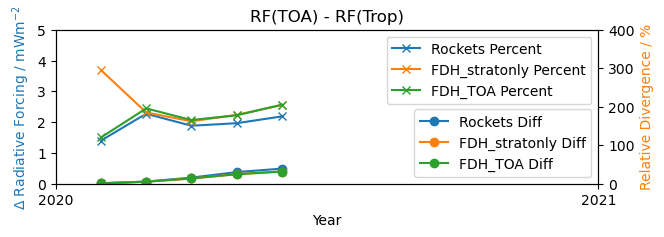

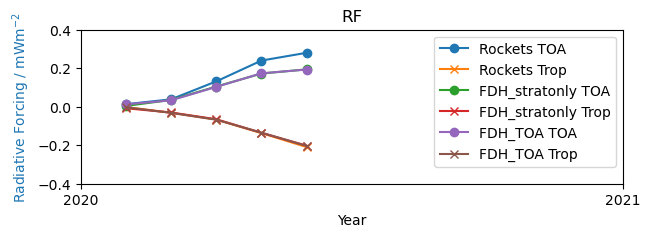

In [14]:
months =['01','02','03','04','05']#,'06','07','08','09','10','11','12']
years = ["2020",]#"2021","2022"]

fig, ax1 = plt.subplots(figsize=(7,2))
ax2 = ax1.twinx()
fig1, ax3 = plt.subplots(figsize=(7,2))

wr_filepaths = ["/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/Rockets",
                "/home/ucfacb0/Scratch/Old_Rocket_Runs/OutputDir/Rockets/FDH_stratonly",
                "/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/Rockets/FDH_TOA"]
for wr_filepath in wr_filepaths:
    rf_diff, rf_toa_plot, rf_trop_plot,rf_toa_percent,year_labels= [],[],[],[],[]
    for year_count,year in enumerate(years):
        for month in months:
            #if (year == "2020" and int(month) > 6) or (year == "2022" and int(month) < 12) or (year == "2021"):
            #if (year == "2022" and int(month) > 11):
                #pass
                #continue  
            year_labels.append(int(month)/12+year_count+2020)      
            # Open the files
            wr  = xr.open_dataset(wr_filepath + f"/GEOSChem.RRTMG.{year}{month}01_0000z.nc4") 
            nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.RRTMG.{year}{month}01_0000z.nc4' )
            time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]

            # Check that the stratospheric adjustment worked.
            flux_toa_perturbed = wr["RadAllSkySWTOA_BASE"].isel(time=0) + wr["RadAllSkyLWTOA_BASE"].isel(time=0)    
            flux_toa_baseline  = nr["RadAllSkySWTOA_BASE"].isel(time=0) + nr["RadAllSkyLWTOA_BASE"].isel(time=0)  
            
            flux_trop_perturbed = wr["RadAllSkySWTrop_BASE"].isel(time=0) + wr["RadAllSkyLWTrop_BASE"].isel(time=0)    
            flux_trop_baseline  = nr["RadAllSkySWTrop_BASE"].isel(time=0) + nr["RadAllSkyLWTrop_BASE"].isel(time=0)
            
            rf_toa  = flux_toa_perturbed  - flux_toa_baseline       
            rf_trop = flux_trop_perturbed - flux_trop_baseline 
            
            diff = rf_toa - rf_trop
            rf_toa_plot.append(rf_toa.mean().item()*1000)
            rf_trop_plot.append(rf_trop.mean().item()*1000)
            rf_diff.append(diff.mean().item()*1000)
            rf_toa_percent.append(diff.mean().item()/rf_toa.mean().item()*100)
            
            wr.close()
            nr.close()

    
    ax1.plot(year_labels,rf_diff,'-o', label=f"{wr_filepath.split('/')[-1]} Diff")
    ax2.plot(year_labels,rf_toa_percent,'-x',label=f"{wr_filepath.split('/')[-1]} Percent")
    ax3.plot(year_labels,rf_toa_plot,'-o',label=f"{wr_filepath.split('/')[-1]} TOA")
    ax3.plot(year_labels,rf_trop_plot,'-x',label=f"{wr_filepath.split('/')[-1]} Trop")
    print(rf_toa_plot,rf_trop_plot)
    
ax1.set_xlabel("Year")
ax1.set_ylabel("$\Delta$ Radiative Forcing / mWm$^{-2}$", color='tab:blue')
ax1.set_xticks(np.linspace(2020,2021,2))
ax1.set_xlim(2020,2021)
ax1.set_ylim(0,5)
ax1.set_title(f"RF(TOA) - RF(Trop)")
ax2.set_ylim(0,400)
ax2.set_ylabel("Relative Divergence / %", color='tab:orange');
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

ax3.set_xlabel("Year")
ax3.set_ylabel("Radiative Forcing / mWm$^{-2}$", color='tab:blue')
ax3.set_xticks(np.linspace(2020,2021,2))
ax3.set_xlim(2020,2021)
ax3.set_ylim(-0.4,0.4)
ax3.set_title(f"RF");
ax3.legend()

In [15]:
#def print_rrtmg(output):
#
#    wr  = xr.open_dataset("/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/Rockets/GEOSChem.RRTMG.20210601_0000z.nc4")
#    fig = plt.figure(figsize=[8,4])
#    ax = plt.axes(projection=ccrs.PlateCarree())
#    ax.coastlines()
#    ax.gridlines(linestyle='--')
#    total = wr[f"RadAllSkyLWTOA_{output}"].isel(time=0) + wr[f"RadAllSkySWTOA_{output}"].isel(time=0)
#    max_range = np.ceil(np.abs(np.max(total)))
#    total.plot(ax=ax, cmap="bwr",vmin=-max_range,vmax=max_range)
#    ax.set_title(f"Rocket Sim All-sky Total TOA RF - {output}")
#    wr.close()
#    
#spec_names = ["O3","ME","SU","NI","AM","BC","OA","SS","DU","PM","ST"]
#interact(print_rrtmg,
#        output=Dropdown(options=spec_names, continuous_update=True),
#        );


In [16]:
# Note this is a MONTHLY diagnostic file so emissions will be summed over the month.
#wr  = xr.open_dataset("/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/Rockets/HEMCO_diagnostics.202201010000.nc")
#print(wr["EmisAl2O3_SMF_Rocket"])
#al2o3 = np.sum(wr["EmisAl2O3_SMF_Rocket"].values)
#dst1  = np.sum(wr["EmisAl2O3_DST1_Rocket"].values)
#dst2  = np.sum(wr["EmisAl2O3_DST2_Rocket"].values)
#dst3  = np.sum(wr["EmisAl2O3_DST3_Rocket"].values)
#dst4  = np.sum(wr["EmisAl2O3_DST4_Rocket"].values)
#print(f'DST1 = {dst1:.2f}  kg\nDST2 = {dst2:.2f} kg\nDST3 = {dst3:.2f} kg\nDST4 = {dst4:.2f} kg')
#print(dst1/np.sum(dst1+dst2+dst3+dst4))
#print(dst2/np.sum(dst1+dst2+dst3+dst4))
#print(dst3/np.sum(dst1+dst2+dst3+dst4))
#print(dst4/np.sum(dst1+dst2+dst3+dst4))
#print(al2o3/np.sum(dst1+dst2+dst3+dst4))
#total_mass = 200*0.4
#wr.close()